In [1]:
# ==============================================================================
# PIPELINE EN GOOGLE COLAB: COMERCIO EXTERIOR PANAMÁ -> COLOMBIA
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------------------
# PASO 1: Ingesta en vivo de la TRM (Dólar en Colombia) vía API pública (Nube)
# ------------------------------------------------------------------------------
print(
    "☁️ [NUBE] Consultando API pública de tipo de cambio en Colombia"
    " (USD/COP)..."
)
try:
  url_trm_api = (
      "https://www.datos.gov.co/resource/32sa-awyu.json?$limit=1&$order=vigenciahasta%20DESC"
  )
  res = requests.get(url_trm_api, timeout=5)
  data_trm = res.json()
  trm_actual_api = float(data_trm[0]["valor"])
  print(
      f"✅ TRM Oficial obtenida en vivo desde la nube: ${trm_actual_api:,.2f}"
      " COP"
  )
except Exception as e:
  trm_actual_api = 4000.0
  print(
      "⚠️ No se pudo conectar a la API. Usando TRM base por defecto:"
      f" ${trm_actual_api:,.2f} COP"
  )

# ------------------------------------------------------------------------------
# PASO 2: Simulación e Ingestión de Dataset Cloud de Exportaciones
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 1500

dates = pd.date_range(start="2025-01-01", periods=n_samples, freq="h")
hs_codes = np.random.choice(
    ["8517.62", "8431.49", "9018.90", "3004.90"],
    size=n_samples,
    p=[0.4, 0.3, 0.15, 0.15],
)
puertos = np.random.choice(
    ["Cartagena", "Buenaventura", "Santa Marta"],
    size=n_samples,
    p=[0.5, 0.35, 0.15],
)
valor_fob = np.random.uniform(15000, 250000, n_samples)
peso_kg = valor_fob * np.random.uniform(0.04, 0.18, n_samples)
trm_usd_cop = np.random.uniform(
    trm_actual_api - 200, trm_actual_api + 200, n_samples
)

# Probabilidad de retenido en aduana (Canal Rojo)
prob_retention = (
    0.08
    + (valor_fob > 120000) * 0.25
    + (puertos == "Buenaventura") * 0.20
    + (hs_codes == "8517.62") * 0.10
)
prob_retention = np.clip(prob_retention, 0, 1)
retraso_aduanero = np.random.binomial(1, prob_retention)

df_exportaciones = pd.DataFrame({
    "fecha_embarque": dates,
    "hs_code": hs_codes,
    "puerto_destino": puertos,
    "valor_fob_usd": valor_fob,
    "peso_kg": peso_kg,
    "trm_usd_cop": trm_usd_cop,
    "retraso_aduanero": retraso_aduanero,
})

print(
    f"\n📦 Dataset de exportaciones cargado en memoria de Colab:"
    f" {len(df_exportaciones)} filas."
)

# ------------------------------------------------------------------------------
# PASO 3: Entrenamiento del Modelo de Machine Learning (Random Forest)
# ------------------------------------------------------------------------------
df_encoded = pd.get_dummies(
    df_exportaciones, columns=["hs_code", "puerto_destino"], drop_first=True
)

X = df_encoded.drop(columns=["fecha_embarque", "retraso_aduanero"])
y = df_encoded["retraso_aduanero"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)

print(f"🧠 Modelo Random Forest entrenado. ROC-AUC Score: {auc_score:.3f}")


# ------------------------------------------------------------------------------
# PASO 4: Motor de Recomendación Comercial (Incoterms & Pricing)
# ------------------------------------------------------------------------------
def cotizar_exportacion_panama(
    fob_usd, puerto, hs_code, trm_actual, proyeccion_devaluacion_pct
):
  # Crear vector dummy para predicción del envío
  sample = pd.DataFrame([{
      "valor_fob_usd": fob_usd,
      "peso_kg": fob_usd * 0.10,
      "trm_usd_cop": trm_actual,
      "hs_code_8431.49": 1 if hs_code == "8431.49" else 0,
      "hs_code_8517.62": 1 if hs_code == "8517.62" else 0,
      "hs_code_9018.90": 1 if hs_code == "9018.90" else 0,
      "puerto_destino_Cartagena": 1 if puerto == "Cartagena" else 0,
      "puerto_destino_Santa Marta": 1 if puerto == "Santa Marta" else 0,
  }])

  # Asegurar orden de columnas
  sample = sample.reindex(columns=X.columns, fill_value=0)

  # Predicción de probabilidad de retención por inspección aduanera
  prob_retraso = clf.predict_proba(sample)[0][1]

  # Lógica de Decisión Comercial (Incoterm)
  if prob_retraso > 0.35 or proyeccion_devaluacion_pct > 2.5:
    incoterm = "FOB Zona Libre de Colón"
    precio_final = fob_usd
    explicacion = (
        f"El riesgo de canal rojo ({prob_retraso*100:.1f}%) o devaluación es"
        " elevado. Se recomienda vender FOB para que el comprador asuma flete,"
        " aduana y riesgo cambiario."
    )
  else:
    incoterm = "DDP Colombia (Puesto en Destino)"
    costo_flete_seguro = 2400.0 + (fob_usd * 0.005)
    recargo_riesgo = prob_retraso * 1000.0
    precio_final = fob_usd + costo_flete_seguro + recargo_riesgo
    explicacion = (
        f"Riesgo logístico bajo ({prob_retraso*100:.1f}%). Ofrecer DDP permite"
        " servicializar la entrega y capturar mayor margen comercial."
    )

  return {
      "Incoterm Sugerido": incoterm,
      "Precio Propuesto (USD)": f"${precio_final:,.2f}",
      "Probabilidad Inspección Aduanera": f"{prob_retraso*100:.1f}%",
      "TRM Base Usada": f"${trm_actual:,.2f} COP",
      "Estrategia Prescriptiva": explicacion,
  }


# ------------------------------------------------------------------------------
# PASO 5: Simulación de Cotización en Tiempo Real
# ------------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🎯 EVALUACIÓN DE EMBARQUE COMERCIAL (ZONA LIBRE DE COLÓN -> COLOMBIA)")
print("=" * 60)

resultado = cotizar_exportacion_panama(
    fob_usd=130000.0,
    puerto="Buenaventura",
    hs_code="8517.62",
    trm_actual=trm_actual_api,
    proyeccion_devaluacion_pct=3.0,
)

for clave, valor in resultado.items():
  print(f"• {clave}: {valor}")

☁️ [NUBE] Consultando API pública de tipo de cambio en Colombia (USD/COP)...
⚠️ No se pudo conectar a la API. Usando TRM base por defecto: $4,000.00 COP

📦 Dataset de exportaciones cargado en memoria de Colab: 1500 filas.
🧠 Modelo Random Forest entrenado. ROC-AUC Score: 0.661

🎯 EVALUACIÓN DE EMBARQUE COMERCIAL (ZONA LIBRE DE COLÓN -> COLOMBIA)
• Incoterm Sugerido: FOB Zona Libre de Colón
• Precio Propuesto (USD): $130,000.00
• Probabilidad Inspección Aduanera: 69.0%
• TRM Base Usada: $4,000.00 COP
• Estrategia Prescriptiva: El riesgo de canal rojo (69.0%) o devaluación es elevado. Se recomienda vender FOB para que el comprador asuma flete, aduana y riesgo cambiario.


/tmp/ipykernel_1867/1214265682.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1867/1214265682.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Verde (Sin Retraso)", "Rojo (Canal Inspección)"])


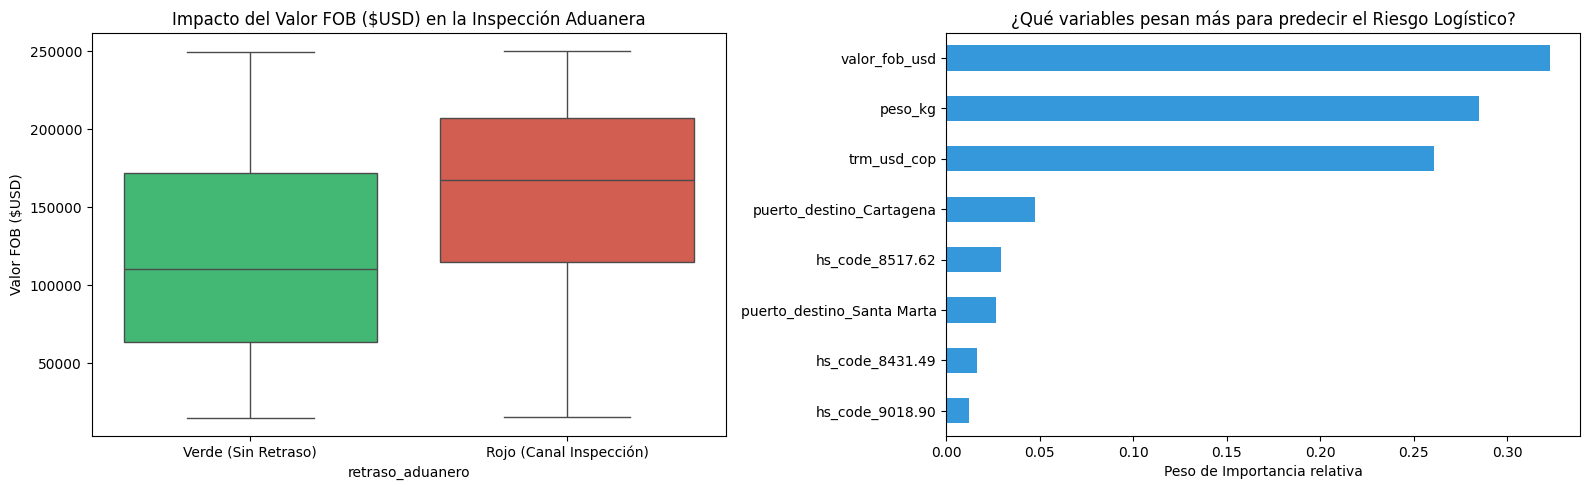

In [2]:
# ==============================================================================
# PASO 6: VISUALIZACIÓN DE RESULTADOS E IMPORTANCIA DE VARIABLES (XAI)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de Distribución del Valor FOB según Retraso Aduanero
import seaborn as sns

sns.boxplot(
    data=df_exportaciones,
    x="retraso_aduanero",
    y="valor_fob_usd",
    ax=axes[0],
    palette=["#2ecc71", "#e74c3c"],
)
axes[0].set_title(
    "Impacto del Valor FOB ($USD) en la Inspección Aduanera", fontsize=12
)
axes[0].set_xticklabels(["Verde (Sin Retraso)", "Rojo (Canal Inspección)"])
axes[0].set_ylabel("Valor FOB ($USD)")

# 2. Importancia de Variables en el Modelo (Feature Importance)
importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values(
    ascending=True
)
importancias.plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title(
    "¿Qué variables pesan más para predecir el Riesgo Logístico?", fontsize=12
)
axes[1].set_xlabel("Peso de Importancia relativa")

plt.tight_layout()
plt.show()

erás controles desplegables y deslizadores en Colab. Puedes mover el valor del contenedor, cambiar de puerto (ej. pasar de Buenaventura a Cartagena) o aumentar la devaluación esperada, y verás cómo el recuadro cambia de color verde (DDP) a rojo (FOB) calculando automáticamente el precio ideal en USD y el riesgo de aduana.

In [3]:
# ==============================================================================
# PASO 6: SIMULADOR INTERACTIVO COMERCIAL CON WIDGETS
# ==============================================================================

from IPython.display import HTML, display
import ipywidgets as widgets

# Definir perillas y controles interactivos
fob_slider = widgets.IntSlider(
    value=120000,
    min=15000,
    max=250000,
    step=5000,
    description="Valor FOB (USD):",
    style={"description_width": "initial"},
)
puerto_dropdown = widgets.Dropdown(
    options=["Cartagena", "Buenaventura", "Santa Marta"],
    value="Buenaventura",
    description="Puerto Destino:",
    style={"description_width": "initial"},
)
hs_dropdown = widgets.Dropdown(
    options=[
        ("Electrónica (8517.62)", "8517.62"),
        ("Repuestos Ind. (8431.49)", "8431.49"),
        ("Medicina (9018.90)", "9018.90"),
    ],
    value="8517.62",
    description="Partida Arancelaria:",
    style={"description_width": "initial"},
)
deval_slider = widgets.FloatSlider(
    value=2.0,
    min=0.0,
    max=8.0,
    step=0.5,
    description="Riesgo Devaluación (%):",
    style={"description_width": "initial"},
)


def simulador_en_vivo(fob_usd, puerto, hs_code, proyeccion_devaluacion_pct):
  res = cotizar_exportacion_panama(
      fob_usd=fob_usd,
      puerto=puerto,
      hs_code=hs_code,
      trm_actual=trm_actual_api,
      proyeccion_devaluacion_pct=proyeccion_devaluacion_pct,
  )

  # Color dinámico: Rojo para alto riesgo (FOB), Verde para bajo riesgo (DDP)
  color_banner = "#c0392b" if "FOB" in res["Incoterm Sugerido"] else "#27ae60"

  html_output = f"""
    <div style="background-color: {color_banner}; color: white; padding: 20px; border-radius: 10px; font-family: sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.3);">
        <h2 style="margin-top:0; font-size: 22px;">📋 Recomendación: {res['Incoterm Sugerido']}</h2>
        <p style="font-size: 16px;"><b>💰 Precio Propuesto:</b> {res['Precio Propuesto (USD)']}</p>
        <p style="font-size: 16px;"><b>🚨 Probabilidad Canal Rojo:</b> {res['Probabilidad Inspección Aduanera']}</p>
        <p style="font-size: 16px;"><b>💵 TRM en Vivo:</b> {res['TRM Base Usada']}</p>
        <hr style="border: 1px solid rgba(255,255,255,0.4);">
        <p style="font-size: 14px;"><b>💡 Justificación de Negocio:</b> {res['Estrategia Prescriptiva']}</p>
    </div>
    """
  display(HTML(html_output))


print(
    "🎛️ SIMULADOR EN VIVOLOGÍSTICA & PRICING (Mueve los controles para recalcular"
    " en tiempo real):\n"
)
widgets.interact(
    simulador_en_vivo,
    fob_usd=fob_slider,
    puerto=puerto_dropdown,
    hs_code=hs_dropdown,
    proyeccion_devaluacion_pct=deval_slider,
)

🎛️ SIMULADOR EN VIVOLOGÍSTICA & PRICING (Mueve los controles para recalcular en tiempo real):



interactive(children=(IntSlider(value=120000, description='Valor FOB (USD):', max=250000, min=15000, step=5000…

<function __main__.simulador_en_vivo(fob_usd, puerto, hs_code, proyeccion_devaluacion_pct)>